In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 32.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=36c28a8af8c2c35baa3ba39fcc3fc065c542c9631ed7154b9d0d4db32c59e847
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# 1. Define Registers
q = QuantumRegister(3, 'q')
anc = QuantumRegister(2, 'ancilla')
syn = ClassicalRegister(2, 'syndrome')
res = ClassicalRegister(3, 'result')
qc = QuantumCircuit(q, anc, syn, res)

# 2. Encoding into X-basis
qc.x(q[0])
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])
qc.h(q) # "Change to X Basis" for all data qubits
qc.barrier()

# 3. Simulate Error (Example: Z error on Q1)
# Use a standard Z gate; avoid naming it 'Error' to prevent AerErrors
qc.z(q[1])
qc.barrier()

# 4. Syndrome Measurement (Parity Checks)
# Map phase flips to bit flips for ancilla detection
qc.h(q)
qc.cx(q[0], anc[0])
qc.cx(q[1], anc[0])
qc.cx(q[1], anc[1])
qc.cx(q[2], anc[1])
qc.barrier()

qc.h(q)
qc.measure(anc, syn)
qc.barrier()

# 5. Conditional Correction (Dynamic logic)
# Corrects Q1 if syndrome is '11' (binary 3)
with qc.if_test((syn, 3)):
    qc.z(q[1])
# Add similar if_tests for other syndrome patterns (01 for Q0, 10 for Q2)
with qc.if_test((syn, 1)):
    qc.z(q[0])
with qc.if_test((syn, 2)):
    qc.z(q[2])

qc.barrier()

# 6. Final Measurement
qc.h(q)
qc.measure(q, res)

# Run with Transpilation
sim = AerSimulator()
qc_t = transpile(qc, sim)
counts = sim.run(qc_t).result().get_counts()
print(counts)


{'111 11': 1024}


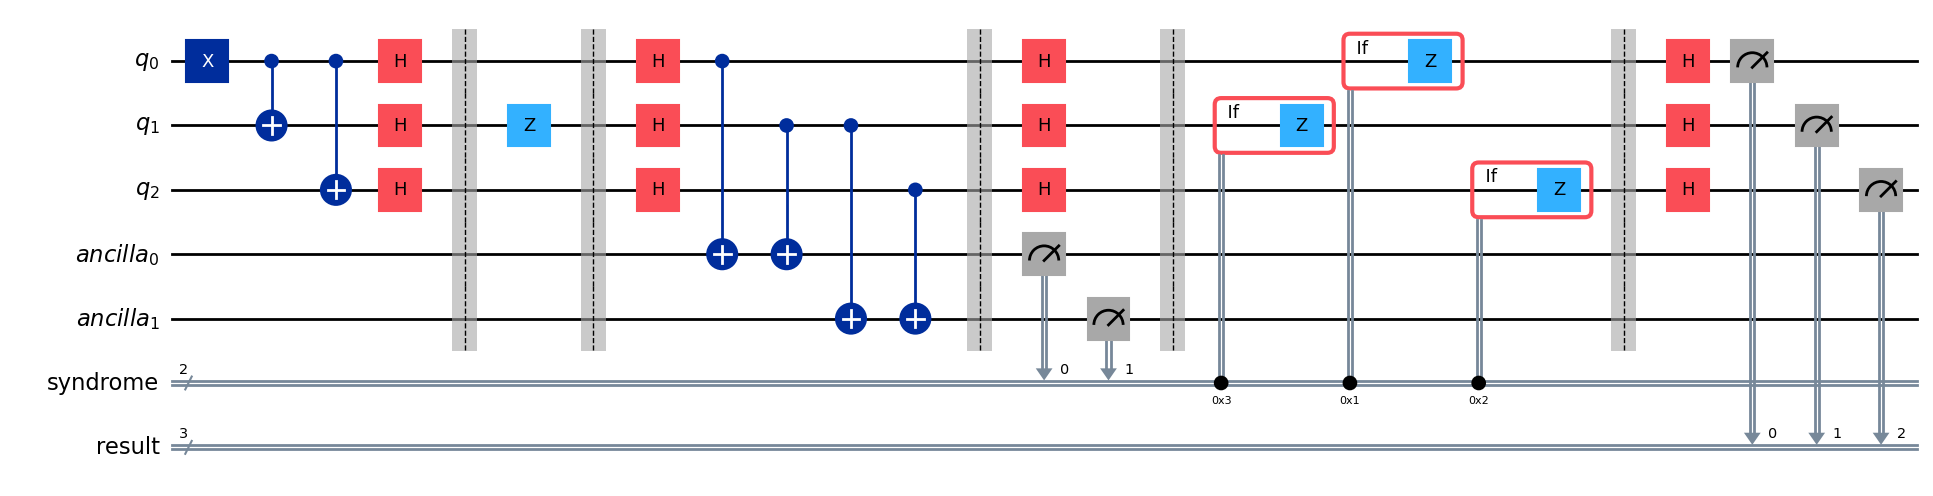

In [3]:
qc.draw(output="mpl", fold=1)